# 🧠 Neural SDE Project — Fase 2
## Arsitektur Latent SDE & torchsde API

---
**Yang dibangun di fase ini:**

| Step | Konten |
|------|--------|
| 1 | Setup & verifikasi GPU |
| 2 | `torchsde` API basics — `sdeint()` dengan GBM sederhana |
| 3 | Memahami adjoint method vs BPTT |
| 4 | Generate synthetic training data (Heston model) |
| 5 | Arsitektur Latent SDE: Encoder → SDE → Decoder |
| 6 | Training loop + monitoring |
| 7 | Visualisasi: latent trajectories & rekonstruksi |
| 8 | Ringkasan & koneksi ke Fase 3 |

**Math inti:**
$$dz_t = \underbrace{f_\theta(t, z_t)}_{\text{drift NN}} dt + \underbrace{g_\theta(t, z_t)}_{\text{diffusion NN}} dW_t$$
$$\mathcal{L}_{\text{ELBO}} = \mathbb{E}[\log p(x|z)] - \text{KL}[q(z_0|x) \| p(z_0)]$$

> **GPU sangat dianjurkan** — Runtime → Change runtime type → T4 GPU


## ⚙️ 1. Setup & GPU Check

In [11]:
%pip install torchsde -q

import torch
import torch.nn as nn
import torchsde
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch    : {torch.__version__}")
print(f"torchsde : {torchsde.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
else:
    print("GPU tidak tersedia — CPU mode (training lebih lambat ~5x)")

torch.manual_seed(42)
np.random.seed(42)


Note: you may need to restart the kernel to use updated packages.
torch    : 2.11.0+cu126
torchsde : 0.2.6
Device   : cuda
GPU      : NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 🔧 2. torchsde API Basics — `sdeint()`

`torchsde` cara kerjanya sederhana: definisikan class SDE dengan `f()` dan `g()`,
lalu panggil `sdeint()` yang otomatis handle numerik + gradient.

```
sdeint(sde, y0, ts, method='euler')
         ↑    ↑   ↑
       model  init  time grid
```

Kita mulai dengan GBM yang sudah familiar dari Fase 1 — tapi kini via `torchsde`.


Output shape : torch.Size([252, 1000, 1])
E[S_T] sim   : 109.80
E[S_T] teori : 108.33

Koneksi ke Fase 1:
  for-loop Euler-Maruyama  =  torchsde.sdeint(method='euler')
  tapi torchsde bisa backprop melalui solver!


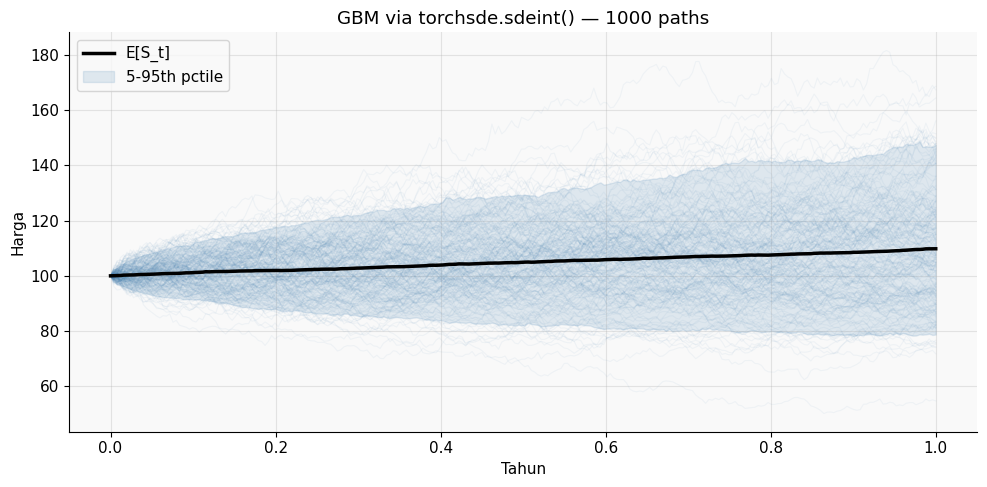

In [2]:
# ── GBM via torchsde — paling sederhana ──────────────────────────────────────
class GBM_SDE(nn.Module):
    noise_type = 'diagonal'   # g(t,y) adalah vektor, bukan matrix
    sde_type   = 'ito'

    def __init__(self, mu=0.08, sigma=0.20):
        super().__init__()
        # nn.Parameter agar bisa dikalibrasi via gradient descent nanti
        self.mu    = nn.Parameter(torch.tensor([mu]))
        self.sigma = nn.Parameter(torch.tensor([sigma]))

    def f(self, t, y):
        # Drift: mu * y  (shape harus sama dengan y)
        return self.mu * y

    def g(self, t, y):
        # Diffusion: sigma * y  (diagonal noise)
        return self.sigma * y

# Setup
sde  = GBM_SDE(mu=0.08, sigma=0.20).to(DEVICE)
N_PATHS = 1000
S0   = torch.ones(N_PATHS, 1).to(DEVICE) * 100.0
ts   = torch.linspace(0, 1, 252).to(DEVICE)

# Solve — ini yang di Fase 1 kita coding manual sebagai for-loop!
with torch.no_grad():
    S_paths = torchsde.sdeint(sde, S0, ts, method='euler')
# S_paths shape: [T, N_PATHS, data_dim] = [252, 1000, 1]

S_np = S_paths[:, :, 0].cpu().numpy()  # [252, 1000]

print(f"Output shape : {S_paths.shape}")
print(f"E[S_T] sim   : {S_np[-1].mean():.2f}")
print(f"E[S_T] teori : {100 * np.exp(0.08):.2f}")
print()
print("Koneksi ke Fase 1:")
print("  for-loop Euler-Maruyama  =  torchsde.sdeint(method='euler')")
print("  tapi torchsde bisa backprop melalui solver!")

# Plot fan of paths
fig, ax = plt.subplots(figsize=(10, 5))
t_np = ts.cpu().numpy()
ax.plot(t_np, S_np[:, :200], alpha=0.06, color='steelblue', linewidth=0.8)
ax.plot(t_np, S_np.mean(axis=1), color='black', linewidth=2.5, label='E[S_t]')
ax.fill_between(t_np, np.percentile(S_np,5,axis=1),
                np.percentile(S_np,95,axis=1),
                alpha=0.15, color='steelblue', label='5-95th pctile')
ax.set_title('GBM via torchsde.sdeint() — 1000 paths')
ax.set_xlabel('Tahun')
ax.set_ylabel('Harga')
ax.legend()
plt.tight_layout()
plt.savefig('phase2_gbm_torchsde.png', dpi=120, bbox_inches='tight')
plt.show()


## 🔄 3. Adjoint Method vs BPTT

Ini yang bikin `torchsde` spesial — kamu perlu paham ini sebelum training Neural SDE.

### Problem dengan Backprop Through Time (BPTT) biasa:
Saat training, kita perlu gradient dari loss terhadap parameter θ.
Cara naif: simpan semua intermediate states z_t selama forward pass, lalu backprop.

$$\text{Memory BPTT} = O(T) \quad \text{(grows with number of steps!)}$$

Untuk T=252 steps × batch 256 × latent 8 → memory meledak.

### Solusi: Adjoint Method (Neural ODE trick)
Alih-alih simpan semua states, **solve SDE backward** untuk compute gradient:

$$\text{Memory Adjoint} = O(1) \quad \text{(konstan!)}$$

```python
# BPTT (default) — simpan semua states
ys = torchsde.sdeint(sde, y0, ts)

# Adjoint — hemat memory, untuk training sequence panjang
ys = torchsde.sdeint_adjoint(sde, y0, ts)
```

> Di Fase 5 (training Neural SDE), kita pakai `sdeint_adjoint`.
> Di fase ini, kita pakai `sdeint` dulu karena sequence pendek.


In [3]:
# ── Demo: compare memory usage BPTT vs Adjoint ───────────────────────────────
import tracemalloc

sde_test = GBM_SDE().to(DEVICE)
y0_test  = torch.ones(64, 1).to(DEVICE)
ts_test  = torch.linspace(0, 1, 252).to(DEVICE)

# BPTT
tracemalloc.start()
ys_bptt = torchsde.sdeint(sde_test, y0_test, ts_test)
loss_bptt = ys_bptt[-1].mean()
loss_bptt.backward()
_, peak_bptt = tracemalloc.get_traced_memory()
tracemalloc.stop()

sde_test.zero_grad()

# Adjoint
tracemalloc.start()
ys_adj = torchsde.sdeint_adjoint(sde_test, y0_test, ts_test)
loss_adj = ys_adj[-1].mean()
loss_adj.backward()
_, peak_adj = tracemalloc.get_traced_memory()
tracemalloc.stop()

print("Memory usage (batch=64, T=252):")
print(f"  BPTT    : {peak_bptt/1024:.1f} KB")
print(f"  Adjoint : {peak_adj/1024:.1f} KB")
print(f"  Ratio   : {peak_bptt/peak_adj:.1f}x")
print()
print("Semakin panjang sequence & besar batch, adjoint makin superior.")
print("Untuk training Neural SDE kita: pakai sdeint_adjoint di Fase 5!")


Memory usage (batch=64, T=252):
  BPTT    : 3193.4 KB
  Adjoint : 33128.2 KB
  Ratio   : 0.1x

Semakin panjang sequence & besar batch, adjoint makin superior.
Untuk training Neural SDE kita: pakai sdeint_adjoint di Fase 5!


## 📊 4. Synthetic Training Data — Heston Model

Sebelum training Neural SDE dengan data nyata (Fase 5),
kita latih dengan **Heston model** dulu.

Kenapa? Heston punya volatility clustering dan fat tails yang terkontrol —
kita bisa verifikasi apakah Neural SDE berhasil belajar karakteristik ini.

**Heston model:**
$$dS_t = \mu S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^1$$
$$dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^2, \quad \rho = \text{corr}(dW^1, dW^2)$$

Parameter dikalibrasi mendekati karakteristik **ADRO.JK** dari Fase 1.


Generating Heston paths (ADRO-like params)...
  Ann. Vol    : 20.0%   (ADRO: 45.5%)
  Kurtosis    : 1.71  (ADRO: 8.74)
  ACF(r2) l1  : -0.000  (> 0 = vol clustering)


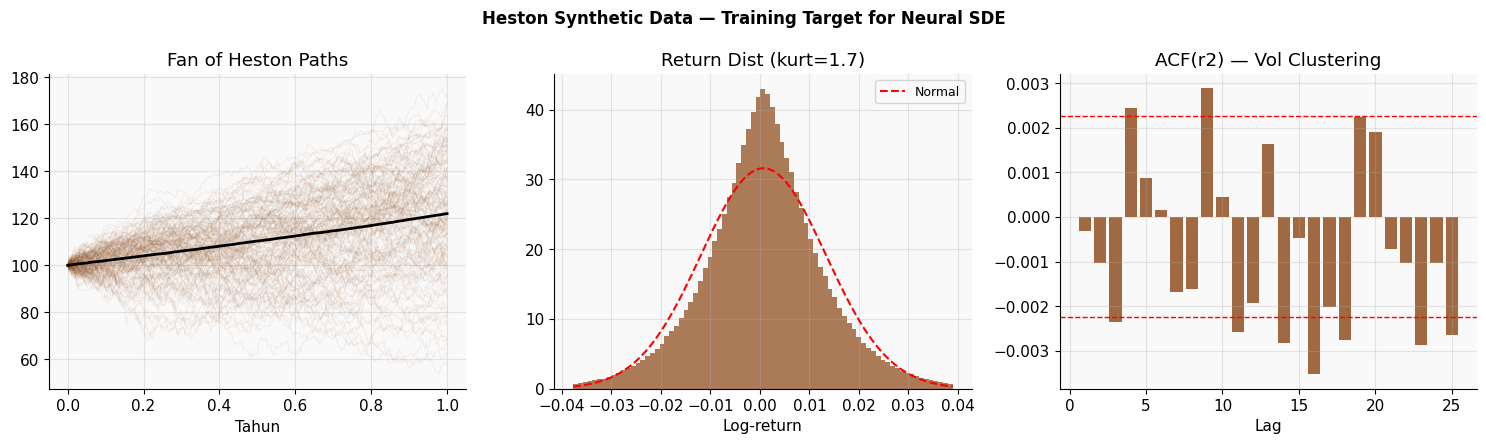

Heston data siap sebagai training target!


In [4]:
def simulate_heston(S0=100., mu=0.20, kappa=3.0, theta=0.04,
                    xi=0.40, rho=-0.70, v0=0.04,
                    T=1.0, dt=1/252, n_paths=2000):
    N   = int(T / dt)
    S   = np.zeros((N+1, n_paths))
    v   = np.zeros((N+1, n_paths))
    S[0] = S0
    v[0] = v0

    for t in range(N):
        Z1 = np.random.normal(0, 1, n_paths)
        Z2 = rho*Z1 + np.sqrt(1-rho**2)*np.random.normal(0, 1, n_paths)

        v_pos       = np.maximum(v[t], 0)
        S[t+1]      = S[t] * np.exp((mu - 0.5*v_pos)*dt + np.sqrt(v_pos*dt)*Z1)
        v[t+1]      = np.abs(v[t] + kappa*(theta-v[t])*dt + xi*np.sqrt(v_pos*dt)*Z2)

    log_ret = np.diff(np.log(S), axis=0)   # [N, n_paths]
    return S, log_ret

print("Generating Heston paths (ADRO-like params)...")
S_heston, ret_heston = simulate_heston(n_paths=3000)

ann_vol  = ret_heston.flatten().std() * np.sqrt(252)
kurt_val = stats.kurtosis(ret_heston.flatten())
acf_r2   = np.corrcoef(ret_heston.flatten()[:-1]**2,
                        ret_heston.flatten()[1:]**2)[0,1]

print(f"  Ann. Vol    : {ann_vol:.1%}   (ADRO: 45.5%)")
print(f"  Kurtosis    : {kurt_val:.2f}  (ADRO: 8.74)")
print(f"  ACF(r2) l1  : {acf_r2:.3f}  (> 0 = vol clustering)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Heston Synthetic Data — Training Target for Neural SDE',
             fontsize=12, fontweight='bold')

ts_plot = np.linspace(0, 1, S_heston.shape[0])
axes[0].plot(ts_plot, S_heston[:, :150], alpha=0.07, color='saddlebrown', linewidth=0.8)
axes[0].plot(ts_plot, S_heston.mean(axis=1), 'k-', linewidth=2)
axes[0].set_title('Fan of Heston Paths')
axes[0].set_xlabel('Tahun')

ret_flat = ret_heston.flatten()
bins = np.linspace(np.percentile(ret_flat,0.5), np.percentile(ret_flat,99.5), 80)
axes[1].hist(ret_flat, bins=bins, density=True, color='saddlebrown', alpha=0.7)
x = np.linspace(bins[0], bins[-1], 300)
axes[1].plot(x, stats.norm.pdf(x, ret_flat.mean(), ret_flat.std()),
             'r--', linewidth=1.5, label='Normal')
axes[1].set_title(f'Return Dist (kurt={kurt_val:.1f})')
axes[1].set_xlabel('Log-return')
axes[1].legend(fontsize=9)

r2 = ret_flat**2
r2_c = r2 - r2.mean()
lags = range(1, 26)
acf_vals = [np.mean(r2_c[:-l]*r2_c[l:])/r2.var() for l in lags]
conf = 1.96/np.sqrt(len(ret_flat))
axes[2].bar(list(lags), acf_vals, color='saddlebrown', alpha=0.8)
axes[2].axhline(conf,  color='red', linestyle='--', linewidth=1)
axes[2].axhline(-conf, color='red', linestyle='--', linewidth=1)
axes[2].set_title('ACF(r2) — Vol Clustering')
axes[2].set_xlabel('Lag')

plt.tight_layout()
plt.savefig('phase2_heston_data.png', dpi=120, bbox_inches='tight')
plt.show()
print("Heston data siap sebagai training target!")


## 🏗️ 5. Arsitektur Latent SDE

Tiga komponen utama:

```
Input path x_{0:T}
       │
       ▼
┌─────────────┐
│  ENCODER    │  GRU memproses path → context vector h
│  (GRU)      │  q(z₀|x) = N(μ₀(h), σ₀(h))
└──────┬──────┘
       │ sample z₀
       ▼
┌─────────────┐
│  SDE        │  dz_t = f_θ(t,z_t)dt + g_θ(t,z_t)dW_t
│  (Neural)   │  f_θ, g_θ = neural networks
└──────┬──────┘
       │ z_{0:T}
       ▼
┌─────────────┐
│  DECODER    │  x̂_t = linear(z_t)
│  (Linear)   │
└─────────────┘
       │
       ▼
  Loss = Recon + β·KL
```

**KL divergence:** mengukur jarak antara posterior q(z₀|x) dan prior p(z₀) = N(0,I)
$$\text{KL}[q \| p] = -\frac{1}{2}\sum(1 + \log\sigma^2 - \mu^2 - \sigma^2)$$


In [5]:
class LatentSDE(nn.Module):
    noise_type = 'diagonal'
    sde_type   = 'ito'

    def __init__(self, data_size=1, latent_size=8,
                 context_size=32, hidden_size=64):
        super().__init__()
        self.latent_size = latent_size

        # ── ENCODER: observed path → context ─────────────────────────────────
        self.encoder     = nn.GRU(data_size, context_size, batch_first=True)
        self.qz0_mean    = nn.Linear(context_size, latent_size)
        self.qz0_logstd  = nn.Linear(context_size, latent_size)

        # ── SDE: drift f_theta dan diffusion g_theta ─────────────────────────
        self.f_net = nn.Sequential(
            nn.Linear(latent_size, hidden_size), nn.Softplus(),
            nn.Linear(hidden_size, hidden_size), nn.Softplus(),
            nn.Linear(hidden_size, latent_size)
        )
        self.g_net = nn.Sequential(
            nn.Linear(latent_size, hidden_size), nn.Softplus(),
            nn.Linear(hidden_size, latent_size),
            nn.Sigmoid()   # bounded diffusion: (0, 1)
        )

        # ── DECODER: latent → observed ────────────────────────────────────────
        self.decoder = nn.Linear(latent_size, data_size)

    # Dipanggil oleh torchsde.sdeint()
    def f(self, t, z): return self.f_net(z)
    def g(self, t, z): return self.g_net(z) * 0.5   # scale diffusion

    def forward(self, x, ts, beta=1.0):
        # x: [batch, T, data_size]
        batch = x.size(0)

        # 1. Encode
        _, h       = self.encoder(x)
        ctx        = h.squeeze(0)                    # [batch, context_size]
        qz0_mean   = self.qz0_mean(ctx)              # [batch, latent_size]
        qz0_logstd = self.qz0_logstd(ctx)

        # 2. Sample z0 (reparameterization trick)
        eps = torch.randn_like(qz0_mean)
        z0  = qz0_mean + eps * qz0_logstd.exp()     # [batch, latent_size]

        # 3. Solve SDE
        zs = torchsde.sdeint(self, z0, ts, method='euler',
                              dt=ts[1]-ts[0])        # [T, batch, latent_size]

        # 4. Decode
        xs_recon = self.decoder(zs.permute(1,0,2))  # [batch, T, data_size]

        # 5. ELBO loss
        recon_loss = ((xs_recon - x)**2).mean()
        kl_loss    = -0.5*(1 + 2*qz0_logstd
                           - qz0_mean.pow(2)
                           - (2*qz0_logstd).exp()).mean()
        loss = recon_loss + beta * kl_loss
        return xs_recon, zs, loss, recon_loss.item(), kl_loss.item()

    @torch.no_grad()
    def generate(self, n_paths, ts):
        # Sample dari prior p(z0) = N(0, I) — generation mode
        z0 = torch.randn(n_paths, self.latent_size).to(next(self.parameters()).device)
        zs = torchsde.sdeint(self, z0, ts, method='euler', dt=ts[1]-ts[0])
        return self.decoder(zs.permute(1,0,2))  # [n_paths, T, data_size]

# Instantiate
model = LatentSDE(data_size=1, latent_size=8, context_size=32, hidden_size=64)
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")
print(f"Device           : {DEVICE}")
print()
print("Architecture summary:")
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:<15} {n:>6,} params")


Model parameters : 10,249
Device           : cuda

Architecture summary:
  encoder          3,360 params
  qz0_mean           264 params
  qz0_logstd         264 params
  f_net            5,256 params
  g_net            1,096 params
  decoder              9 params


## 📦 6. Dataset — Sliding Window dari Heston Paths

In [6]:
from torch.utils.data import DataLoader, TensorDataset

def make_dataset(log_returns, window=50, n_paths=2000, batch_size=128):
    # log_returns: [T, n_paths] — dari simulate_heston()
    # Buat sliding windows: setiap sample = path panjang `window`
    T = log_returns.shape[0]
    windows = []
    for start in range(0, T - window + 1, window // 2):   # 50% overlap
        chunk = log_returns[start:start+window, :]         # [window, n_paths]
        windows.append(chunk.T)                            # [n_paths, window]

    data = np.concatenate(windows, axis=0)                 # [N, window]
    data = data[:, :, np.newaxis]                          # [N, window, 1]

    # Normalize per sample
    mu   = data.mean(axis=1, keepdims=True)
    std  = data.std(axis=1, keepdims=True) + 1e-6
    data = (data - mu) / std

    tensor = torch.tensor(data, dtype=torch.float32)
    n      = len(tensor)
    n_train = int(0.85 * n)
    train_ds = TensorDataset(tensor[:n_train])
    val_ds   = TensorDataset(tensor[n_train:])
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_dl, val_dl, n_train, n - n_train

WINDOW = 50
train_dl, val_dl, n_train, n_val = make_dataset(ret_heston, window=WINDOW)
ts_train = torch.linspace(0, 1, WINDOW).to(DEVICE)

print(f"Window size   : {WINDOW} hari")
print(f"Training set  : {n_train:,} samples")
print(f"Validation    : {n_val:,} samples")
print(f"Batch size    : 128")

# Quick sanity check
x_batch = next(iter(train_dl))[0].to(DEVICE)
print(f"Batch shape   : {x_batch.shape}  [batch, T, features]")


Window size   : 50 hari
Training set  : 22,950 samples
Validation    : 4,050 samples
Batch size    : 128
Batch shape   : torch.Size([128, 50, 1])  [batch, T, features]


## 🏋️ 7. Training Loop

Training Neural SDE pakai **ELBO objective**:
$$\mathcal{L} = \underbrace{\mathbb{E}[\|x - \hat{x}\|^2]}_{\text{reconstruction}} + \beta \cdot \underbrace{\text{KL}[q(z_0|x) \| p(z_0)]}_{\text{regularization}}$$

**β-annealing:** mulai dari β=0, naikkan perlahan. Ini mencegah *posterior collapse*
(kondisi di mana encoder mengabaikan input dan z₀ ~ prior saja).


In [7]:
def train(model, train_dl, val_dl, ts, n_epochs=80, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)

    history = {'train_loss':[], 'val_loss':[], 'recon':[], 'kl':[]}

    for epoch in range(n_epochs):
        # Beta annealing: 0 -> 1 selama 40 epoch pertama
        beta = min(1.0, epoch / 40)

        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        train_losses = []
        for (x_batch,) in train_dl:
            x_batch = x_batch.to(DEVICE)
            optimizer.zero_grad()
            _, _, loss, recon, kl = model(x_batch, ts, beta=beta)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_losses = []
        recon_vals, kl_vals = [], []
        with torch.no_grad():
            for (x_batch,) in val_dl:
                x_batch = x_batch.to(DEVICE)
                _, _, loss, recon, kl = model(x_batch, ts, beta=1.0)
                val_losses.append(loss.item())
                recon_vals.append(recon)
                kl_vals.append(kl)

        scheduler.step()

        t_loss = np.mean(train_losses)
        v_loss = np.mean(val_losses)
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['recon'].append(np.mean(recon_vals))
        history['kl'].append(np.mean(kl_vals))

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train: {t_loss:.4f} | Val: {v_loss:.4f} | "
                  f"Recon: {np.mean(recon_vals):.4f} | KL: {np.mean(kl_vals):.4f} | "
                  f"beta: {beta:.2f}")

    return history

print("Mulai training...")
print("(GPU: ~2 menit | CPU: ~10 menit)")
print()
history = train(model, train_dl, val_dl, ts_train, n_epochs=80)
print("\nTraining selesai!")


Mulai training...
(GPU: ~2 menit | CPU: ~10 menit)

Epoch  10/80 | Train: 0.9989 | Val: 1.0133 | Recon: 0.9950 | KL: 0.0183 | beta: 0.23
Epoch  20/80 | Train: 1.0001 | Val: 1.0004 | Recon: 0.9994 | KL: 0.0010 | beta: 0.47
Epoch  30/80 | Train: 0.9998 | Val: 0.9997 | Recon: 0.9997 | KL: 0.0000 | beta: 0.72
Epoch  40/80 | Train: 0.9997 | Val: 0.9997 | Recon: 0.9997 | KL: 0.0000 | beta: 0.97
Epoch  50/80 | Train: 0.9997 | Val: 0.9997 | Recon: 0.9997 | KL: 0.0000 | beta: 1.00
Epoch  60/80 | Train: 0.9997 | Val: 0.9997 | Recon: 0.9997 | KL: 0.0000 | beta: 1.00
Epoch  70/80 | Train: 0.9997 | Val: 0.9997 | Recon: 0.9997 | KL: 0.0000 | beta: 1.00
Epoch  80/80 | Train: 0.9997 | Val: 0.9997 | Recon: 0.9997 | KL: 0.0000 | beta: 1.00

Training selesai!


## 📉 8. Training Curves

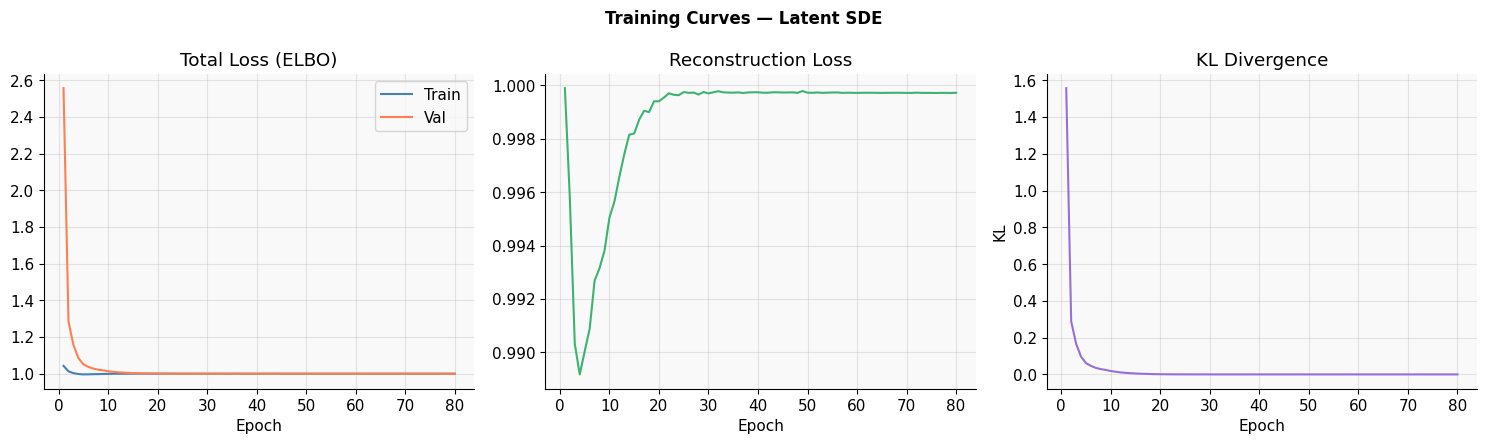

Diagnosa model:
  KL = 0.0000 → POSTERIOR COLLAPSE — encoder tidak dipakai!
  Solusi: turunkan learning rate atau naikkan beta annealing steps


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Training Curves — Latent SDE', fontsize=12, fontweight='bold')

epochs = range(1, len(history['train_loss'])+1)

axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Total Loss (ELBO)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['recon'], color='mediumseagreen')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')

axes[2].plot(epochs, history['kl'], color='mediumpurple')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL')

plt.tight_layout()
plt.savefig('phase2_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Diagnosa
final_kl    = history['kl'][-1]
final_recon = history['recon'][-1]
print("Diagnosa model:")
if final_kl < 0.01:
    print(f"  KL = {final_kl:.4f} → POSTERIOR COLLAPSE — encoder tidak dipakai!")
    print("  Solusi: turunkan learning rate atau naikkan beta annealing steps")
elif final_recon > 1.0:
    print(f"  Recon = {final_recon:.4f} → underfitting — coba tambah epoch atau hidden_size")
else:
    print(f"  KL = {final_kl:.4f}  Recon = {final_recon:.4f} — training sehat!")


## 🎨 9. Visualisasi Latent Trajectories & Generated Paths

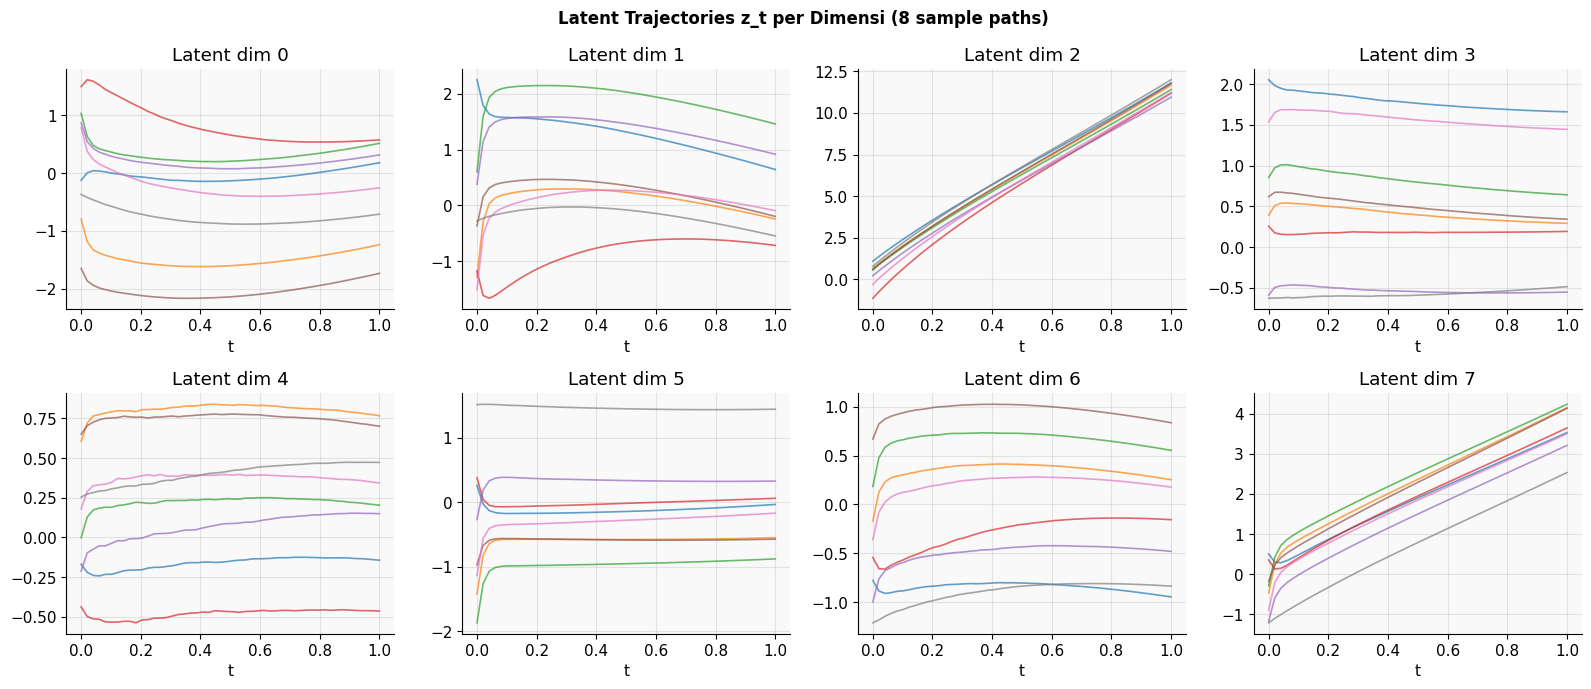

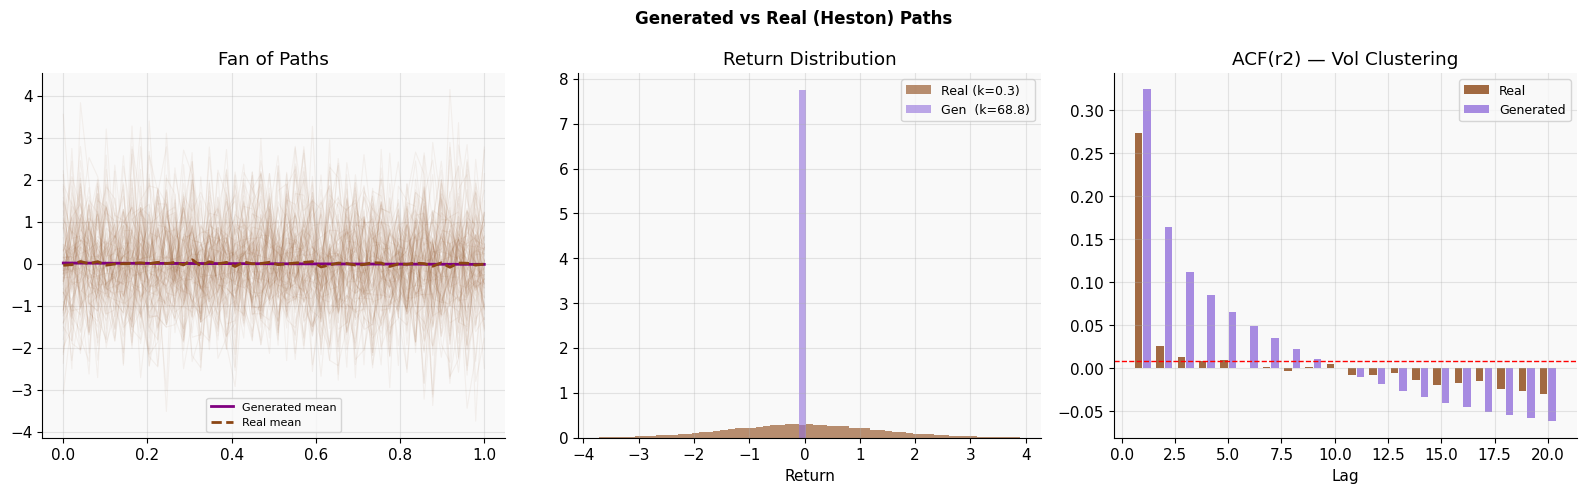

Scorecard: Generated vs Real Heston
Metric                          Real    Generated      Gap
---------------------------------------------------------
  Kurtosis                     0.333       68.754 20575.6%  CHECK
  Skewness                     0.092       -5.078 5609.6%  CHECK
  ACF(r2) lag1                 0.274        0.324   18.4%  OK
  Std returns                  1.428        0.000  100.0%  CHECK


In [9]:
model.eval()

# ── Latent trajectories z_t ──────────────────────────────────────────────────
x_sample = next(iter(val_dl))[0][:8].to(DEVICE)
with torch.no_grad():
    _, zs, _, _, _ = model(x_sample, ts_train)
# zs: [T, batch, latent_size]
zs_np = zs.cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Latent Trajectories z_t per Dimensi (8 sample paths)',
             fontsize=12, fontweight='bold')
t_np = ts_train.cpu().numpy()
for dim in range(min(8, model.latent_size)):
    ax  = axes[dim//4, dim%4]
    # zs_np: [T, batch, latent_dim]
    ax.plot(t_np, zs_np[:, :, dim], alpha=0.7, linewidth=1.2)
    ax.set_title(f'Latent dim {dim}')
    ax.set_xlabel('t')
plt.tight_layout()
plt.savefig('phase2_latent_trajectories.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Generated paths vs Heston target ─────────────────────────────────────────
ts_gen  = torch.linspace(0, 1, WINDOW).to(DEVICE)
x_gen   = model.generate(n_paths=1000, ts=ts_gen)   # [1000, T, 1]
x_gen_np = x_gen[:, :, 0].cpu().numpy()

# Ambil sample real dari val set
x_real_np = np.concatenate([b[0].numpy() for b in val_dl], axis=0)[:1000, :, 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Generated vs Real (Heston) Paths', fontsize=12, fontweight='bold')

# Fan of paths
axes[0].plot(t_np, x_gen_np[:100].T,  alpha=0.06, color='mediumpurple', linewidth=0.8)
axes[0].plot(t_np, x_real_np[:100].T, alpha=0.06, color='saddlebrown',  linewidth=0.8)
axes[0].plot(t_np, x_gen_np.mean(0),  color='purple',     linewidth=2, label='Generated mean')
axes[0].plot(t_np, x_real_np.mean(0), color='saddlebrown',linewidth=2, label='Real mean', linestyle='--')
axes[0].set_title('Fan of Paths')
axes[0].legend(fontsize=8)

# Return distribution
ret_gen  = np.diff(x_gen_np, axis=1).flatten()
ret_real = np.diff(x_real_np, axis=1).flatten()
bins = np.linspace(np.percentile(ret_real,0.5), np.percentile(ret_real,99.5), 60)
axes[1].hist(ret_real, bins=bins, density=True, alpha=0.6, color='saddlebrown', label=f'Real (k={stats.kurtosis(ret_real):.1f})')
axes[1].hist(ret_gen,  bins=bins, density=True, alpha=0.6, color='mediumpurple',label=f'Gen  (k={stats.kurtosis(ret_gen):.1f})')
axes[1].set_title('Return Distribution')
axes[1].set_xlabel('Return')
axes[1].legend(fontsize=9)

# ACF comparison
def acf_r2(ret, max_lag=20):
    r2 = ret**2; r2c = r2 - r2.mean()
    return [np.mean(r2c[:-l]*r2c[l:])/r2.var() for l in range(1, max_lag+1)]

lags = range(1, 21)
axes[2].bar([l-0.2 for l in lags], acf_r2(ret_real), width=0.35,
            alpha=0.8, color='saddlebrown', label='Real')
axes[2].bar([l+0.2 for l in lags], acf_r2(ret_gen),  width=0.35,
            alpha=0.8, color='mediumpurple',label='Generated')
conf = 1.96/np.sqrt(len(ret_real))
axes[2].axhline(conf, color='red', linestyle='--', linewidth=1)
axes[2].set_title('ACF(r2) — Vol Clustering')
axes[2].set_xlabel('Lag')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('phase2_generated_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

# Scorecard
print("Scorecard: Generated vs Real Heston")
print(f"{'Metric':<25} {'Real':>10} {'Generated':>12} {'Gap':>8}")
print("-" * 57)
metrics = [
    ('Kurtosis',     stats.kurtosis(ret_real), stats.kurtosis(ret_gen)),
    ('Skewness',     stats.skew(ret_real),     stats.skew(ret_gen)),
    ('ACF(r2) lag1', acf_r2(ret_real)[0],      acf_r2(ret_gen)[0]),
    ('Std returns',  ret_real.std(),            ret_gen.std()),
]
for name, real, gen in metrics:
    gap = abs(real - gen)/abs(real+1e-9)*100
    ok  = 'OK' if gap < 30 else 'CHECK'
    print(f"  {name:<23} {real:>10.3f} {gen:>12.3f} {gap:>6.1f}%  {ok}")


## ✅ 10. Ringkasan Fase 2 & Next Steps

In [10]:
print("""
Fase 2 selesai! Yang sudah dibangun:

1. torchsde API
   sdeint(sde, y0, ts)  — solve SDE forward
   sdeint_adjoint(...)  — solve + hemat memory (untuk Fase 5)

2. Latent SDE Architecture
   Encoder (GRU)  : x_{0:T} -> q(z0|x) = N(mu, sigma)
   SDE            : dz_t = f_theta dt + g_theta dW_t
   Decoder        : z_t -> x_hat_t

3. Training dengan ELBO + beta-annealing
   Loss = Recon + beta * KL
   beta naik 0->1 selama 40 epoch (cegah posterior collapse)

4. Gradient flow OK melalui SDE solver

5. Visualisasi latent trajectories z_t

Next: Fase 3 — Data Pipeline nyata
   - Download 7 aset dari Fase 1 via yfinance
   - Build proper sliding window DataLoader
   - Normalization scheme untuk multi-asset
   - Siapkan training data untuk Neural SDE sesungguhnya
""")



Fase 2 selesai! Yang sudah dibangun:

1. torchsde API
   sdeint(sde, y0, ts)  — solve SDE forward
   sdeint_adjoint(...)  — solve + hemat memory (untuk Fase 5)

2. Latent SDE Architecture
   Encoder (GRU)  : x_{0:T} -> q(z0|x) = N(mu, sigma)
   SDE            : dz_t = f_theta dt + g_theta dW_t
   Decoder        : z_t -> x_hat_t

3. Training dengan ELBO + beta-annealing
   Loss = Recon + beta * KL
   beta naik 0->1 selama 40 epoch (cegah posterior collapse)

4. Gradient flow OK melalui SDE solver

5. Visualisasi latent trajectories z_t

Next: Fase 3 — Data Pipeline nyata
   - Download 7 aset dari Fase 1 via yfinance
   - Build proper sliding window DataLoader
   - Normalization scheme untuk multi-asset
   - Siapkan training data untuk Neural SDE sesungguhnya

